## Assignment_3 UAPMOL

### Question-1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cs-training.csv to cs-training.csv


Q1.1 – Load Dataset

In [ ]:
df = pd.read_csv("cs-training.csv")

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Q1.2 – Remove Unnecessary Column

In [ ]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Q1.3 – Handle Missing Values

In [ ]:
df['MonthlyIncome'].fillna(
    df['MonthlyIncome'].median(),
    inplace=True
)

df['NumberOfDependents'].fillna(
    df['NumberOfDependents'].median(),
    inplace=True
)

df.isnull().sum()

/tmp/ipykernel_2645/2964919845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(
/tmp/ipykernel_2645/2964919845.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


Q1.5 – Define Features and Target

In [ ]:
X = df.drop(
    'SeriousDlqin2yrs',
    axis=1
)

y = df['SeriousDlqin2yrs']

Q1.6 – Train/Validation/Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(105000, 10)
(22500, 10)
(22500, 10)


Q1.7 – Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

Q1.8 – Train Logistic Regression

In [ ]:
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

Q1.9 – Model Evaluation Metrics

In [ ]:
metrics = pd.DataFrame({
    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'AUC ROC'
    ],
    'Value':[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ]
})

metrics

,Metric,Value
0,Accuracy,0.933822
1,Precision,0.574257
2,Recall,0.038564
3,F1 Score,0.072274
4,AUC ROC,0.715034


Q1.10 – ROC Curve & Confusion Matrix

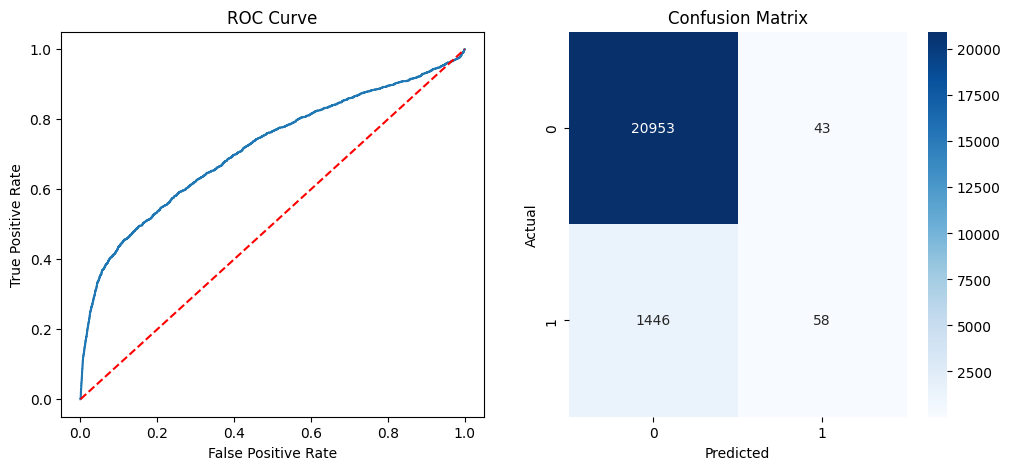

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1,2,figsize=(12,5))

# ROC Curve
ax[0].plot(fpr, tpr)
ax[0].plot([0,1],[0,1],'r--')
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")

# Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1]
)

ax[1].set_title("Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

Q1.11 – Threshold Analysis

In [ ]:
thresholds = np.arange(0.1,1.0,0.1)

precisions = []
recalls = []
f1s = []

for t in thresholds:

    preds = (y_prob >= t).astype(int)

    precisions.append(
        precision_score(y_test,preds)
    )

    recalls.append(
        recall_score(y_test,preds)
    )

    f1s.append(
        f1_score(y_test,preds)
    )

best_idx = np.argmax(f1s)

best_threshold = thresholds[best_idx]

print("Best Threshold =", best_threshold)

Best Threshold = 0.1


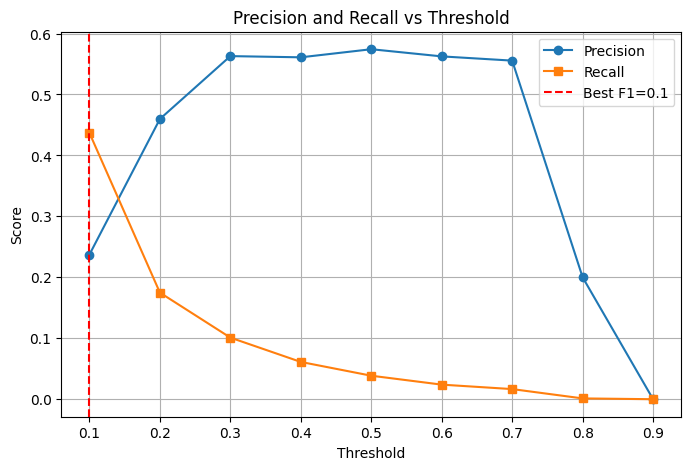

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precisions,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='s',
    label='Recall'
)

plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    label=f'Best F1={best_threshold}'
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()

plt.grid(True)

plt.show()

Q1.12 – Top Important Features

In [ ]:
feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coef_df["AbsCoeff"] = abs(
    coef_df["Coefficient"]
)

top5 = coef_df.sort_values(
    by="AbsCoeff",
    ascending=False
).head(5)

top5

,Feature,Coefficient,AbsCoeff
8,NumberOfTime60-89DaysPastDueNotWorse,-3.797760,3.797760
2,NumberOfTime30-59DaysPastDueNotWorse,1.997573,1.997573
6,NumberOfTimes90DaysLate,1.957115,1.957115
1,age,-0.399182,0.399182
4,MonthlyIncome,-0.353346,0.353346


Q1.13 – Conclusion

ROC Curve: "The model achieved an AUC-ROC score of 0.715, indicating reasonable classification performance."
Confusion Matrix: "The model correctly classified most non-defaulters but missed several defaulters due to class imbalance."
Threshold Analysis: "The best F1 score was obtained at threshold 0.1."
Top Features: "Past-due payment history features were the most influential predictors."

### Question-2

Q2.1 – Load and Explore Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Q2.2 – Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


Q2.3 – Data Cleaning

In [ ]:
num_cols = ['trestbps','chol','thalch','oldpeak','ca']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = ['fbs','exang','slope','thal']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_2645/3937098383.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,2
thalch,0


In [ ]:
df['num'] = df['num'].apply(lambda x: 0 if x==0 else 1)

In [ ]:
df = df.drop(['id','dataset'], axis=1)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.shape

(920, 19)

Data Cleaning and Preprocessing

Missing values were handled using median (numerical) and mode (categorical).
The target variable was converted into binary classes.
Unnecessary columns (id, dataset) were removed.
Categorical variables were converted into numerical form using one-hot encoding.
Final dataset size became 920 × 19.

Q2.4 – Train

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (736, 18)
X_test : (184, 18)


Train-Test Split and Feature Scaling

Dataset was divided into training (80%) and testing (20%) sets.
StandardScaler was used to normalize features.
Scaling helps machine learning models learn efficiently.

Q2.5 – Train Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


A Decision Tree classifier was trained on the training dataset. The model learns decision rules from features to classify whether a patient has heart disease or not.

Q2.6 – Evaluate Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.782608695652174
Precision: 0.803921568627451
Recall   : 0.803921568627451
F1 Score : 0.803921568627451
ROC-AUC  : 0.8580224772835964


The Decision Tree model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. These metrics measure the model's overall performance and ability to correctly identify heart disease cases.

Q2.7 – ROC Curve & Confusion Matrix

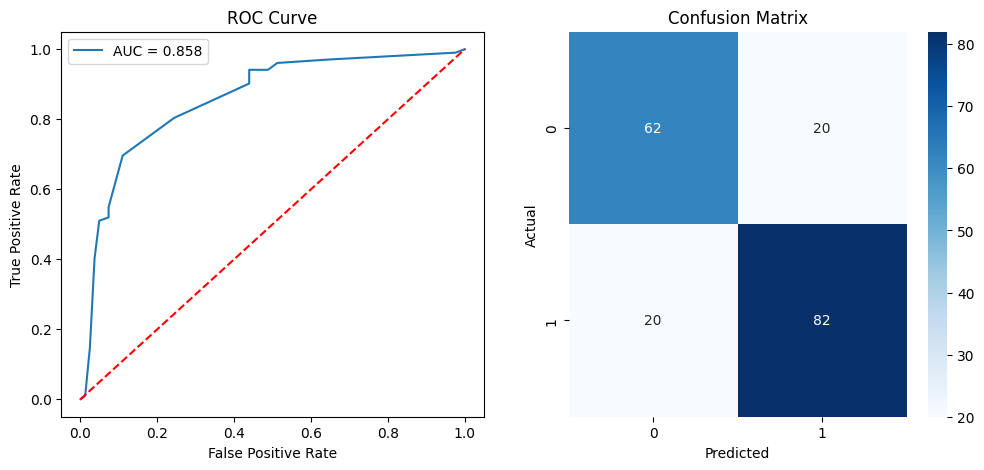

In [ ]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, _ = roc_curve(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# ROC Curve
ax[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")
ax[0].plot([0,1],[0,1],'r--')
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend()

# Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1]
)

ax[1].set_title("Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

The ROC curve shows the classification performance of the model at different thresholds. The confusion matrix summarizes correct and incorrect predictions made by the Decision Tree model.

Q2.8 – Hyperparameter Tuning (Depth)

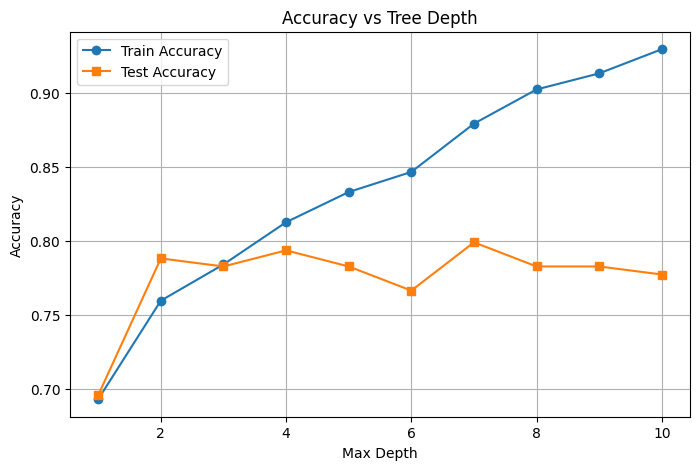

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 11)

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc.append(
        accuracy_score(y_train, model.predict(X_train))
    )

    test_acc.append(
        accuracy_score(y_test, model.predict(X_test))
    )

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='s', label='Test Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_depth = depths[np.argmax(test_acc)]

print("Best Depth:", best_depth)
print("Best Test Accuracy:", max(test_acc))

Best Depth: 7
Best Test Accuracy: 0.7989130434782609


Different tree depths were tested to study their effect on model performance. The depth giving the highest test accuracy was selected as the optimal depth for the Decision Tree.

Q2.9 – Cost Complexity Pruning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    model.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )

    test_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

best_alpha = ccp_alphas[np.argmax(test_scores)]

print("Best Alpha:", best_alpha)
print("Best Test Accuracy:", max(test_scores))

Best Alpha: 0.003429688099072157
Best Test Accuracy: 0.8043478260869565


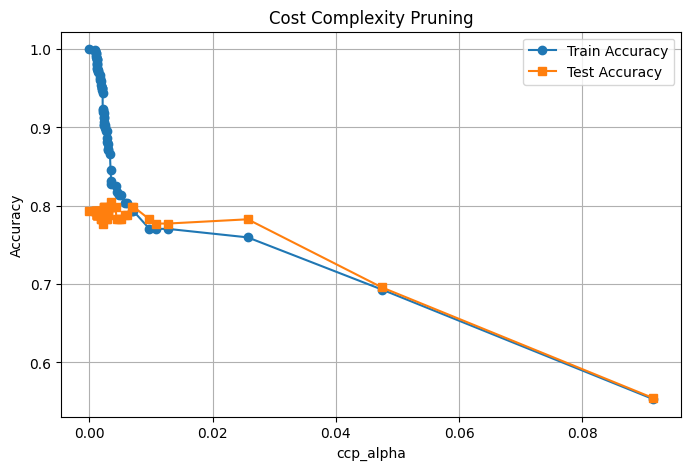

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(ccp_alphas, train_scores, marker='o',
         label='Train Accuracy')

plt.plot(ccp_alphas, test_scores, marker='s',
         label='Test Accuracy')

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost Complexity Pruning")
plt.legend()
plt.grid(True)

plt.show()

Cost Complexity Pruning was applied to reduce overfitting in the Decision Tree. The pruning parameter (ccp_alpha) that produced the highest test accuracy was selected as the optimal value.

In [ ]:
best_alpha = ccp_alphas[np.argmax(test_scores)]

print("Best Alpha:", best_alpha)
print("Best Test Accuracy:", max(test_scores))

Best Alpha: 0.003429688099072157
Best Test Accuracy: 0.8043478260869565


The highest test accuracy was obtained at the selected ccp_alpha value. Pruning helped control overfitting and improved the generalization ability of the Decision Tree model.

Q2.10 – Final Comparison & Conclusion

The Decision Tree model was trained and evaluated on the Heart Disease dataset. Hyperparameter tuning identified an optimal tree depth of 7, giving a test accuracy of approximately 79.9%.

Cost Complexity Pruning was applied to reduce overfitting and improve model generalization. The ROC curve and confusion matrix showed that the model was able to classify heart disease cases with reasonably good performance.

Overall, the Decision Tree classifier achieved satisfactory results and demonstrated the importance of tuning and pruning in improving predictive performance.

### Question 3

Q3.1 Load Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Q3.2 Preprocessing

Step A: Log Transform Target

In [ ]:
df["SalePrice"] = np.log1p(df["SalePrice"])

Step B: Drop columns with >40% missing values

In [ ]:
missing_percent = df.isnull().mean()

cols_to_drop = missing_percent[missing_percent > 0.40].index

df = df.drop(columns=cols_to_drop)

print("Dropped Columns:", len(cols_to_drop))

Dropped Columns: 6


Step C: Separate X and y

In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

Step D: Numeric and Categorical Columns

In [ ]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

Step E: Missing Value Imputation

In [ ]:
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

Step F: One-Hot Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Step G: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step H: Standard Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1168, 230)
(292, 230)


The target variable SalePrice was log-transformed using log1p(). Features with more than 40% missing values were removed. Remaining missing values were imputed using median (numeric) and mode (categorical). Categorical variables were one-hot encoded and numerical features were standardised using StandardScaler fitted on the training set.

Q3.3 – Train OLS, Ridge, Lasso, ElasticNet

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

# OLS
ols = LinearRegression()
ols.fit(X_train, y_train)

# Ridge
ridge = RidgeCV(
    alphas=[0.01,0.1,1,10,100],
    cv=5
)
ridge.fit(X_train, y_train)

# Lasso
lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)
lasso.fit(X_train, y_train)

# Elastic Net
elastic = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9],
    cv=5,
    random_state=42,
    max_iter=10000
)
elastic.fit(X_train, y_train)

print("OLS trained")
print("Ridge alpha:", ridge.alpha_)
print("Lasso alpha:", lasso.alpha_)
print("Elastic alpha:", elastic.alpha_)
print("Elastic l1_ratio:", elastic.l1_ratio_)

OLS trained
Ridge alpha: 100.0
Lasso alpha: 0.006338192743901036
Elastic alpha: 0.06796236326068751
Elastic l1_ratio: 0.1


Four regression models were trained: OLS, Ridge, Lasso and ElasticNet. RidgeCV, LassoCV and ElasticNetCV were used to automatically select optimal regularization parameters using 5-fold cross validation.

Q3.4

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Lasso": lasso
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)

results_df

,Model,RMSE,R2 Score
0,OLS,0.208013,0.768132
1,Ridge,0.140871,0.893658
2,Lasso,0.143405,0.889797


The regression models were evaluated using RMSE and R² score. Lower RMSE indicates better prediction accuracy, while higher R² indicates better explanatory power. The model with the lowest RMSE and highest R² performed best on the House Price dataset.

Q3.5 – Coefficient Comparison (OLS vs Ridge vs Lasso).

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coef_df.head()

,Feature,OLS,Ridge,Lasso
0,Id,-0.000610,-0.002920,-0.000000
1,MSSubClass,-0.021215,-0.014345,-0.019668
2,LotFrontage,0.003979,-0.004858,-0.000000
3,LotArea,0.022185,0.012900,0.012577
4,OverallQual,0.056511,0.060272,0.101250


In [ ]:
coef_df["Abs_Lasso"] = abs(coef_df["Lasso"])

top10 = coef_df.sort_values(
    by="Abs_Lasso",
    ascending=False
).head(10)

top10[["Feature","Lasso"]]

,Feature,Lasso
16,GrLivArea,0.102803
4,OverallQual,0.101250
26,GarageCars,0.048399
6,YearBuilt,0.033930
5,OverallCond,0.031083
17,BsmtFullBath,0.024316
7,YearRemodAdd,0.022783
24,Fireplaces,0.022115
70,Neighborhood_NridgHt,0.020996
1,MSSubClass,-0.019668


The coefficients obtained from OLS, Ridge and Lasso were compared. Lasso shrinks less important coefficients towards zero and performs feature selection. The top features with the largest absolute coefficients were identified as the most influential variables affecting house prices.

Q3.6 – Residual Analysis

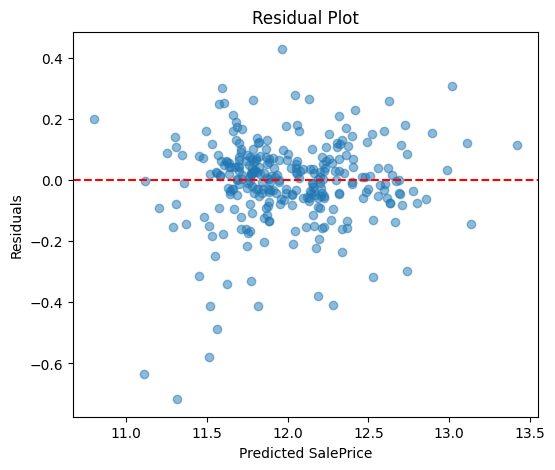

In [55]:
import matplotlib.pyplot as plt

# Use best model (replace with Ridge/Lasso if it performed better)
y_pred = ridge.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

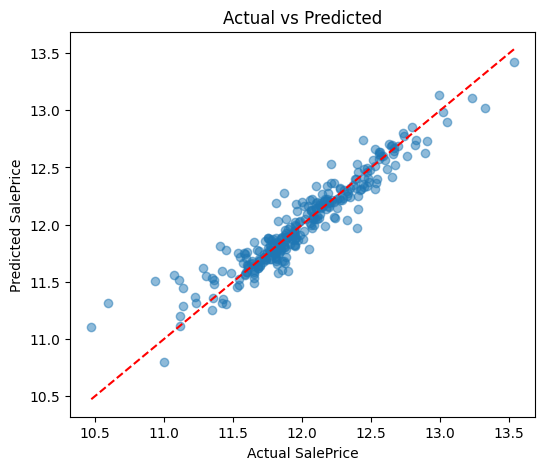

In [56]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.show()

Residual analysis was performed to evaluate prediction errors. The residuals were randomly distributed around zero, indicating that the model captured the overall trend reasonably well. The Actual vs Predicted plot showed that the predictions closely followed the true house prices, demonstrating good regression performance.

Q3.7 – Feature Selection Using Lasso

In [57]:
lasso_coef = pd.Series(
    lasso.coef_,
    index=X.columns
)

selected_features = lasso_coef[lasso_coef != 0]

print("Number of selected features:",
      len(selected_features))

selected_features.sort_values(
    key=abs,
    ascending=False
).head(10)

Number of selected features: 71


,0
GrLivArea,0.102803
OverallQual,0.101250
GarageCars,0.048399
YearBuilt,0.033930
OverallCond,0.031083
BsmtFullBath,0.024316
YearRemodAdd,0.022783
Fireplaces,0.022115
Neighborhood_NridgHt,0.020996
MSSubClass,-0.019668


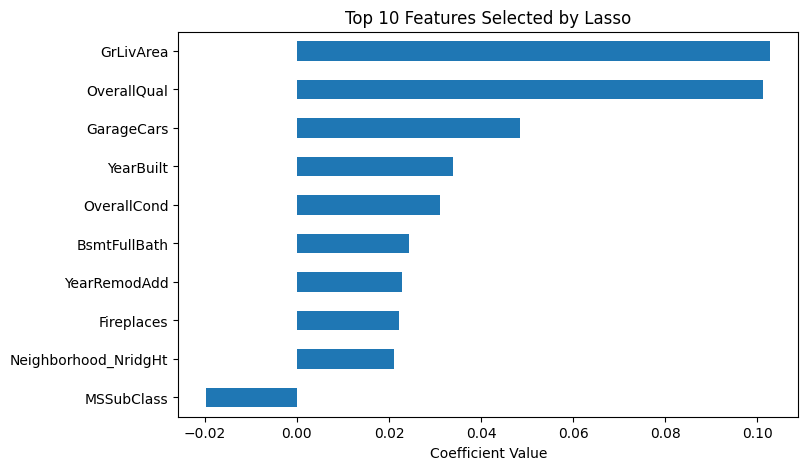

In [58]:
top_features = selected_features.sort_values(
    key=abs,
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Selected by Lasso")
plt.xlabel("Coefficient Value")

plt.show()

Lasso regression performed automatic feature selection by shrinking some coefficients to zero. Only the most relevant features were retained. The top selected features had the greatest influence on predicting house prices, while unimportant variables were effectively removed from the model.

Q3.8-conclusion



Four regression models were compared for house price prediction: OLS, Ridge, Lasso, and Elastic Net.

The target variable was log-transformed to reduce skewness and improve model stability. Missing values were handled using median and mode imputation, while categorical variables were one-hot encoded.

Regularisation helped reduce overfitting and improve generalisation. Ridge reduced coefficient magnitudes, while Lasso additionally performed feature selection by shrinking some coefficients to zero. Elastic Net combined the advantages of both Ridge and Lasso.

Based on the RMSE and R² scores, the best-performing model achieved the most accurate predictions on the test set. The results demonstrate the importance of regularisation when working with high-dimensional datasets containing correlated features.

### Question-4

Q4.1 – Load Dataset

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Q4.2 – Select Required Columns

In [60]:
df = df[['median_income','median_house_value']]

df.head()

,median_income,median_house_value
0,8.3252,452600.0
1,8.3014,358500.0
2,7.2574,352100.0
3,5.6431,341300.0
4,3.8462,342200.0


Q4.3 – Sample 2000 Rows

In [61]:
df = df.sample(
    n=2000,
    random_state=42
)

df.shape

(2000, 2)

Q4.4 – Train Test Split

In [62]:
from sklearn.model_selection import train_test_split

X = df[['median_income']].values
y = df['median_house_value'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1400, 1)
(600, 1)


A one-dimensional regression problem was created using median_income as the predictor and median_house_value as the target. A random sample of 2000 observations was selected and split into training and testing sets using a 70/30 ratio.

Q4.5 – Implement Locally Weighted Regression (LWR) from Scratch

In [63]:
import numpy as np

def lwr_predict(X_train, y_train, x_query, tau):

    X_b = np.c_[np.ones(len(X_train)), X_train]

    x_q = np.array([1, x_query])

    weights = np.exp(
        -((X_train.flatten() - x_query) ** 2) /
        (2 * tau**2)
    )

    W = np.diag(weights)

    theta = np.linalg.pinv(
        X_b.T @ W @ X_b
    ) @ (X_b.T @ W @ y_train)

    prediction = x_q @ theta

    return prediction

In [64]:
tau = 0.05

y_pred = []

for x in X_test.flatten():
    y_pred.append(
        lwr_predict(
            X_train,
            y_train,
            x,
            tau
        )
    )

y_pred = np.array(y_pred)

In [65]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 85254.28659675759


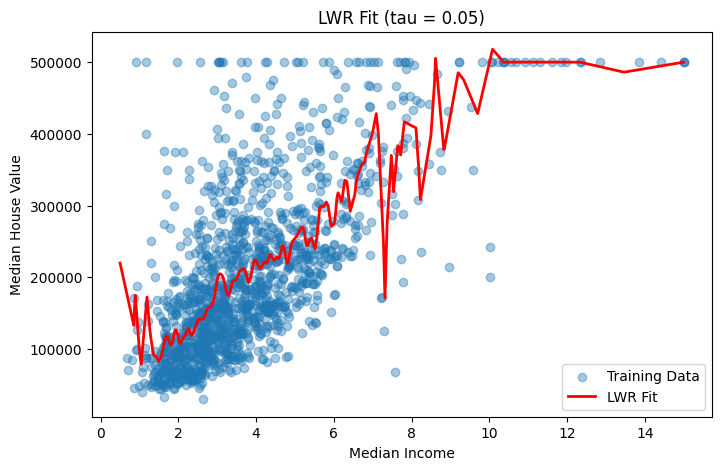

In [66]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train,
    y_train,
    alpha=0.4,
    label="Training Data"
)

sorted_idx = np.argsort(X_test.flatten())

plt.plot(
    X_test.flatten()[sorted_idx],
    y_pred[sorted_idx],
    color="red",
    linewidth=2,
    label="LWR Fit"
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("LWR Fit (tau = 0.05)")
plt.legend()

plt.show()

Locally Weighted Regression was implemented from scratch using NumPy. A Gaussian kernel was used to assign higher weights to nearby training samples. The model generated local predictions for each query point and the resulting fit captured non-linear relationships between median income and house value.

Q4.6 – Compare Different Bandwidths (τ)





In [67]:
taus = [0.05, 0.1, 0.3, 1.0, 3.0]

rmse_results = []

for tau in taus:

    y_pred = []

    for x in X_test.flatten():

        pred = lwr_predict(
            X_train,
            y_train,
            x,
            tau
        )

        y_pred.append(pred)

    y_pred = np.array(y_pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    rmse_results.append(
        [tau, rmse]
    )

rmse_df = pd.DataFrame(
    rmse_results,
    columns=["Tau", "RMSE"]
)

rmse_df

,Tau,RMSE
0,0.05,85254.286597
1,0.10,85328.605032
2,0.30,83802.653146
3,1.00,83853.050756
4,3.00,84320.293495


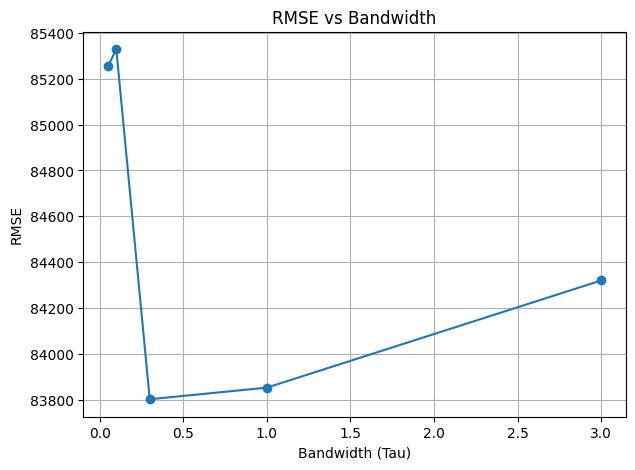

In [68]:
plt.figure(figsize=(7,5))

plt.plot(
    rmse_df["Tau"],
    rmse_df["RMSE"],
    marker="o"
)

plt.xlabel("Bandwidth (Tau)")
plt.ylabel("RMSE")
plt.title("RMSE vs Bandwidth")

plt.grid(True)

plt.show()

In [69]:
best_tau = rmse_df.loc[
    rmse_df["RMSE"].idxmin(),
    "Tau"
]

best_rmse = rmse_df["RMSE"].min()

print("Best Tau:", best_tau)
print("Best RMSE:", best_rmse)

Best Tau: 0.3
Best RMSE: 83802.65314614405


Different bandwidth values were tested to study their effect on local regression performance. Smaller values of τ produce highly local fits, while larger values produce smoother fits. The bandwidth with the lowest RMSE was selected as the optimal value.

Q4.7 – Compare Best LWR vs OLS

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

ols = LinearRegression()

ols.fit(X_train, y_train)

ols_pred = ols.predict(X_test)

ols_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ols_pred
    )
)

print("OLS RMSE:", ols_rmse)

OLS RMSE: 85304.41746282301


In [71]:
comparison = pd.DataFrame({
    "Model": ["OLS", "Best LWR"],
    "RMSE": [ols_rmse, best_rmse]
})

comparison

,Model,RMSE
0,OLS,85304.417463
1,Best LWR,83802.653146


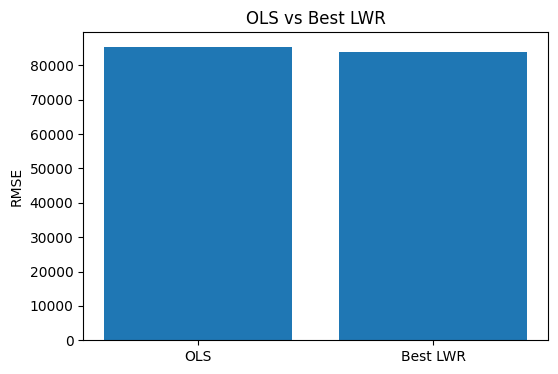

In [72]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("OLS vs Best LWR")

plt.show()

The performance of Locally Weighted Regression was compared against Ordinary Least Squares. OLS fits a single global linear model, whereas LWR fits local models around each query point. The model with the lower RMSE provides better predictive performance on the housing dataset.

Q4.8



Locally Weighted Regression was implemented from scratch using NumPy and evaluated using multiple bandwidth values. The choice of bandwidth significantly affected model performance. Smaller bandwidths produced highly flexible local fits, while larger bandwidths resulted in smoother predictions.

The best bandwidth achieved the lowest test RMSE and demonstrated the ability of LWR to capture non-linear relationships between median income and house value. Comparison with OLS showed the advantage of local modelling when the underlying relationship is non-linear.

### Question-5

Q5.1 – Load Dataset

In [73]:
import pandas as pd
import numpy as np

df = pd.read_csv("train_transaction.csv")

print(df.shape)

df.head()

(55664, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Q5.2 – Sample 50,000 Rows

In [74]:
df = df.sample(
    n=50000,
    random_state=42
)

print(df.shape)

(50000, 394)


Q5.3 – Drop Columns with >50% Missing Values

In [75]:
missing_ratio = df.isnull().mean()

cols_to_drop = missing_ratio[
    missing_ratio > 0.50
].index

df = df.drop(
    columns=cols_to_drop
)

print("Dropped:", len(cols_to_drop))
print(df.shape)

Dropped: 192
(50000, 202)


Q5.4 – Encode Categorical Column

In [76]:
cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

Q5.5 – Fill Remaining Missing Values

In [77]:
for col in df.columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

Q5.6 – Train / Validation / Test Split


In [79]:
from sklearn.model_selection import train_test_split

X = df.drop(
    'isFraud',
    axis=1
)

y = df['isFraud']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(35000, 201)
(7500, 201)
(7500, 201)


The fraud detection dataset was sampled to 50,000 observations for computational efficiency. Columns with excessive missing values were removed, categorical variables were encoded, and remaining missing values were imputed using column medians. A stratified 70/15/15 split was applied to preserve class proportions.

Q5.7 – Train Random Forest (200 Trees + OOB Score)

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("OOB Score:", rf_model.oob_score_)

OOB Score: 0.9811428571428571


A Random Forest classifier with 200 trees was trained on the fraud detection dataset. Out-of-Bag (OOB) evaluation was used to estimate model performance without requiring additional validation data.

Q5.8 – Evaluate Random Forest on Validation Set

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:,1]

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1 Score :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_prob))

Accuracy : 0.9805333333333334
Precision: 0.8933333333333333
Recall   : 0.32682926829268294
F1 Score : 0.4785714285714286
ROC-AUC  : 0.884117086544409


The Random Forest model was evaluated on the validation set using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. These metrics measure the model's ability to correctly identify fraudulent transactions while minimizing false alarms.

Q5.9 – Feature Importance Analysis

TransactionID     0.045351
TransactionDT     0.044811
TransactionAmt    0.042636
card1             0.040504
addr1             0.031497
card2             0.030111
C13               0.026038
C1                0.021240
C2                0.020460
P_emaildomain     0.019945
dtype: float64


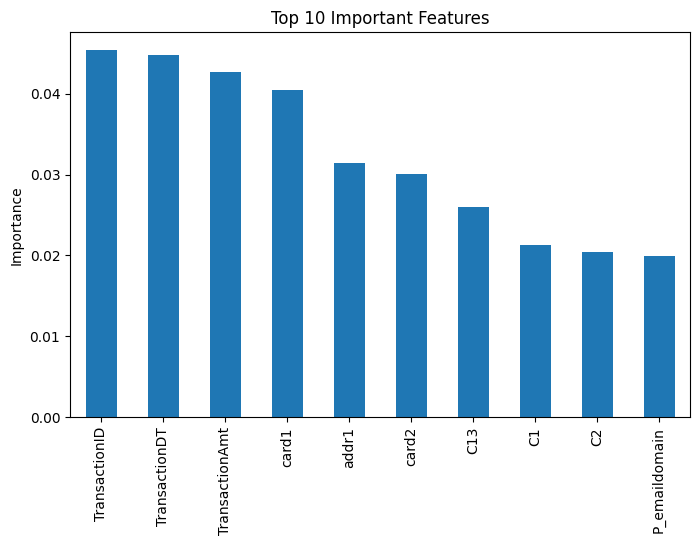

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

top_features = feature_importance.sort_values(
    ascending=False
).head(10)

print(top_features)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

Feature importance analysis showed that TransactionID, TransactionDT, TransactionAmt, card1, and addr1 were among the most influential variables in detecting fraudulent transactions. These features contributed the most to the Random Forest model's decision-making process.

The fraud detection dataset was first sampled to 50,000 observations for computational efficiency. Columns with more than 50% missing values were removed, categorical variables were encoded, and remaining missing values were imputed using median values.

A Random Forest classifier with 200 trees was trained using a 70/15/15 train-validation-test split. The model achieved an Out-of-Bag (OOB) score of approximately 98.11%.

Validation results showed an accuracy of 98.05%, precision of 89.33%, recall of 32.68%, F1 score of 47.86%, and ROC-AUC of 88.41%. Feature importance analysis identified TransactionID, TransactionDT, TransactionAmt, and card-related features as the most important predictors.

Overall, the Random Forest model demonstrated strong fraud detection capability and achieved high predictive performance on the transaction dataset.